In [ ]:
from google.colab import files
uploded = files.upload()


Saving Bitcoin Historical Data.csv to Bitcoin Historical Data.csv


(4999, 7)
Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4999 non-null   object
 1   Price     4999 non-null   object
 2   Open      4999 non-null   object
 3   High      4999 non-null   object
 4   Low       4999 non-null   object
 5   Vol.      4993 non-null   object
 6   Change %  4999 non-null   object
dtypes: object(7)
memory usage: 273.5+ KB
None
        Date  Price  Open  High  Low   Vol. Change %
0 2010-07-18    0.1   0.0   0.1  0.1  0.08K    0.00%
1 2010-07-19    0.1   0.1   0.1  0.1  0.57K    0.00%
2 2010-07-20    0.1   0.1   0.1  0.1  0.26K    0.00%
3 2010-07-21    0.1   0.1   0.1  0.1  0.58K    0.00%
4 2010-07-22    0.1   0.1   0.1  0.1  2.16K    0.00%
<class 'pandas.core.frame.DataFrame'>
Index: 4993 entries, 0 to 4998
Data columns (total 7 co

/tmp/ipykernel_650/965367955.py:15: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


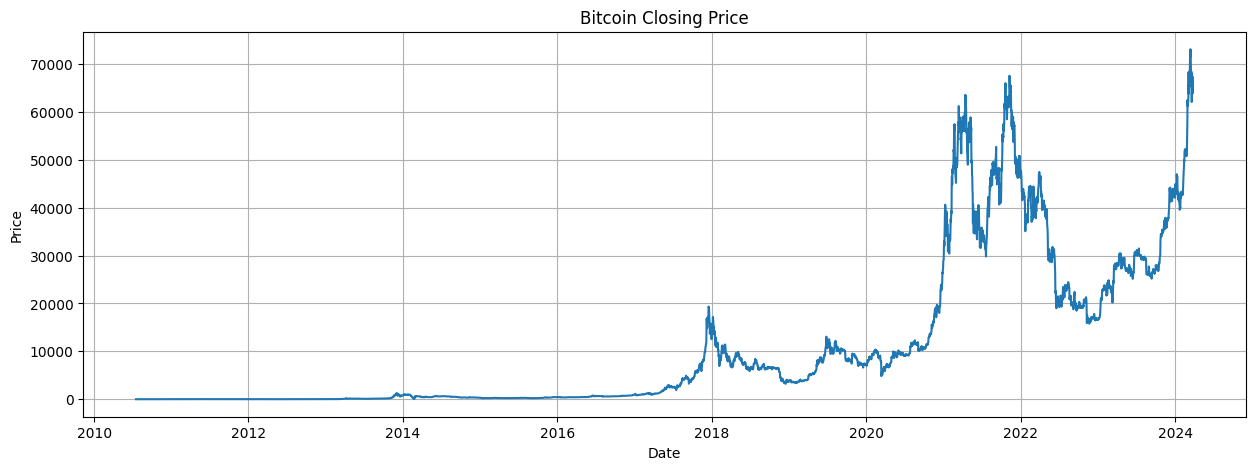

[[0.        ]
 [0.        ]
 [0.        ]
 ...
 [0.87298094]
 [0.87643397]
 [0.9198754 ]]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("Bitcoin Historical Data.csv")

df.head()
print(df.shape)
print(df.columns)
print(df.info())

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Remove commas from numeric columns
numeric_cols = ["Price", "Open", "High", "Low"]

for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing values
df = df.dropna()

print(df.head())
print(df.info())

plt.figure(figsize=(15,5))
plt.plot(df["Date"], df["Price"])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

data = df[["Price"]]

data.head()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print(scaled_data)

In [ ]:
import numpy as np

def create_sequences(data, window_size=60, forecast_horizon=1):

    X = []
    y = []

    for i in range(len(data) - window_size - forecast_horizon + 1):

        X.append(data[i:i+window_size])

        y.append(data[i+window_size:i+window_size+forecast_horizon,0])

    return np.array(X), np.array(y)

X_1d, y_1d = create_sequences(
    scaled_data,
    window_size=60,
    forecast_horizon=1
)

print(X_1d.shape)
print(y_1d.shape)

X_3d, y_3d = create_sequences(
    scaled_data,
    window_size=60,
    forecast_horizon=3
)

print(X_3d.shape)
print(y_3d.shape)

X_7d, y_7d = create_sequences(
    scaled_data,
    window_size=60,
    forecast_horizon=7
)

print(X_7d.shape)
print(y_7d.shape)

train_size = int(len(X_1d) * 0.8)

X_train = X_1d[:train_size]
X_test = X_1d[train_size:]

y_train = y_1d[:train_size]
y_test = y_1d[train_size:]

print(X_train.shape)
print(X_test.shape)

(4933, 60, 1)
(4933, 1)
(4931, 60, 1)
(4931, 3)
(4927, 60, 1)
(4927, 7)
(3946, 60, 1)
(987, 60, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,169 (465.50 KB)

 Trainable params: 119,169 (465.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0014 - mae: 0.0160 - val_loss: 0.0027 - val_mae: 0.0384
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.4043e-04 - mae: 0.0117 - val_loss: 0.0067 - val_mae: 0.0687
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.8104e-04 - mae: 0.0125 - val_loss: 0.0016 - val_mae: 0.0284
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.9670e-04 - mae: 0.0112 - val_loss: 0.0028 - val_mae: 0.0409
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.4604e-04 - mae: 0.0120 - val_loss: 0.0080 - val_mae: 0.0786
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9130e-04 - mae: 0.0118 - val_loss: 0.0037 - val_mae: 0.0501
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.2982e-04 - mae: 0.0123 - val_loss: 0.0018 - val_mae: 0.0328
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.7417e-04 - mae: 0.0123 - val_loss: 0.0018 - val_mae: 0.0320
Epoch 9/50
124/124 ━━━━━━━━

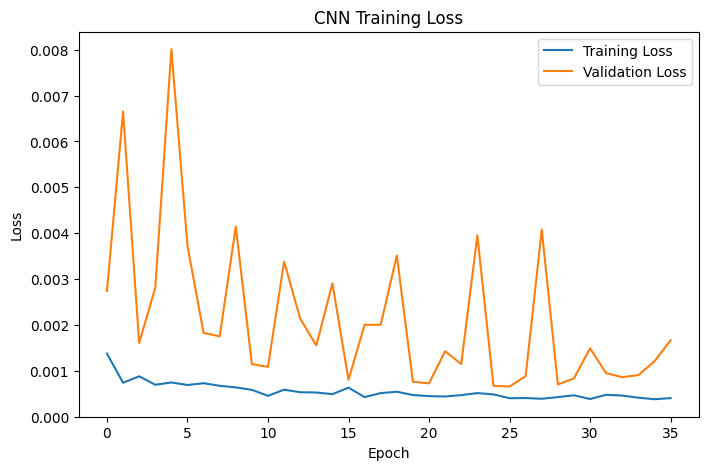

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

cnn_model = Sequential([
    Conv1D(filters=64,
           kernel_size=3,
           activation='relu',
           input_shape=(X_train.shape[1], X_train.shape[2])),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(1)
])

cnn_model.summary()

cnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.legend()

plt.show()

y_pred = cnn_model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred)

MAE : 1306.150319188513
RMSE: 1875.2316529530228
MAPE: 0.03693673058053032


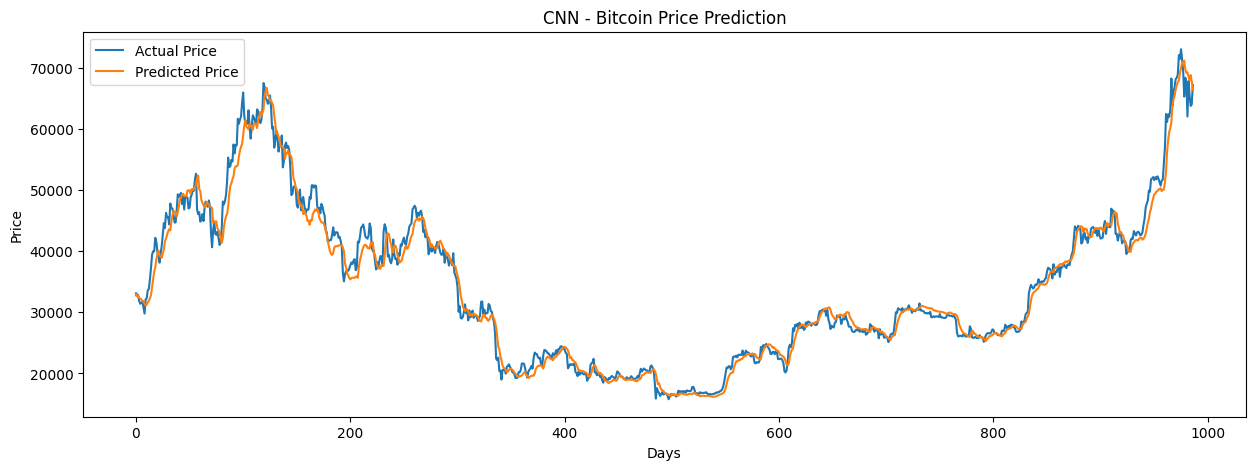

In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_actual)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(y_pred_actual, label="Predicted Price")

plt.title("CNN - Bitcoin Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - loss: 0.0012 - mae: 0.0158 - val_loss: 7.0464e-04 - val_mae: 0.0185
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3288e-04 - mae: 0.0096 - val_loss: 0.0047 - val_mae: 0.0618
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.1144e-04 - mae: 0.0081 - val_loss: 0.0022 - val_mae: 0.0403
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.0191e-04 - mae: 0.0067 - val_loss: 0.0012 - val_mae: 0.0255
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.1068e-04 - mae: 0.0064 - val_loss: 4.4084e-04 - val_mae: 0.0151
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1218e-04 - mae: 0.0087 - val_loss: 0.0016 - val_mae: 0.0325
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.4977e-04 - mae: 0.0077 - val_loss: 0.0020 - val_mae: 0.0372
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0095e-04 - mae: 0.0065 - val_loss: 0.0012 - val_mae: 0.0276
Epoch 9/50
124/12

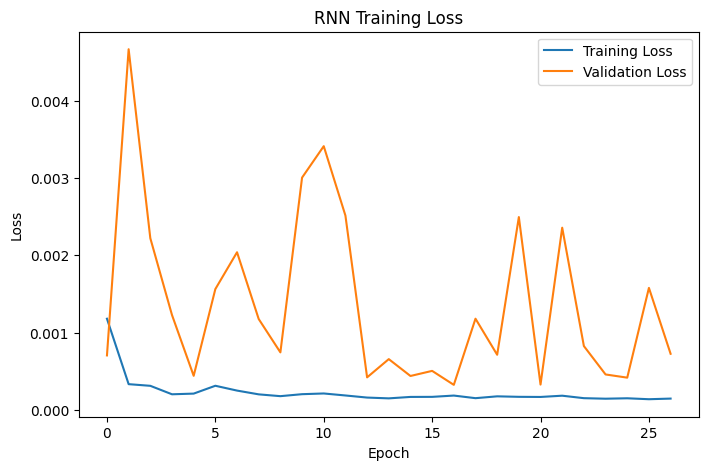

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
MAE : 863.209016630256
RMSE: 1314.7500321693135
MAPE: 0.02393372200918925


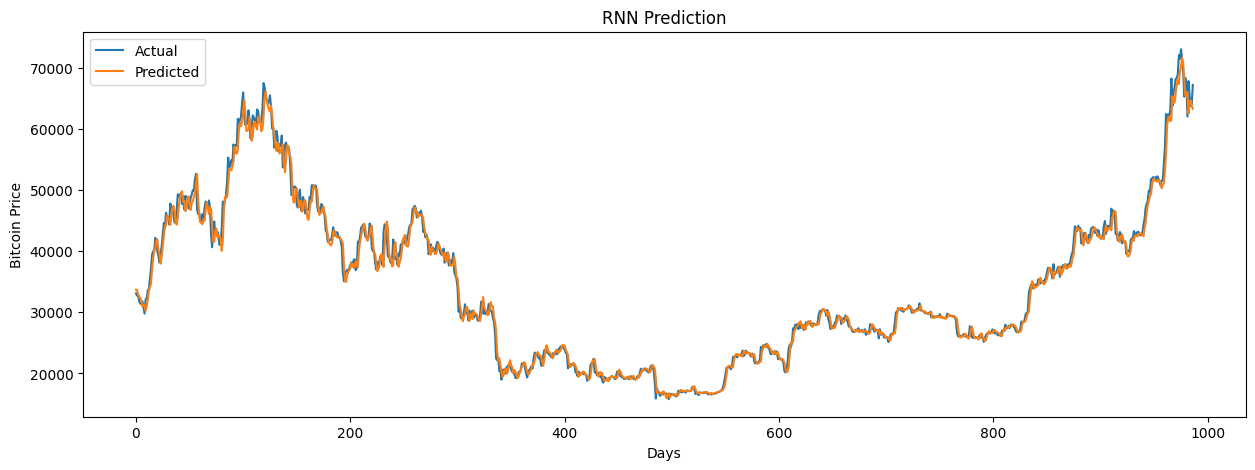

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

import numpy as np

import matplotlib.pyplot as plt

rnn_model = Sequential([
    SimpleRNN(
        units=64,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

rnn_model.summary()

rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


y_pred_rnn = rnn_model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test)
y_pred_rnn_actual = scaler.inverse_transform(y_pred_rnn)

mae_rnn = mean_absolute_error(y_test_actual, y_pred_rnn_actual)
rmse_rnn = np.sqrt(mean_squared_error(y_test_actual, y_pred_rnn_actual))
mape_rnn = mean_absolute_percentage_error(y_test_actual, y_pred_rnn_actual)

print("MAE :", mae_rnn)
print("RMSE:", rmse_rnn)
print("MAPE:", mape_rnn)

plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_rnn_actual, label="Predicted")

plt.title("RNN Prediction")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0015 - mae: 0.0178 - val_loss: 0.0017 - val_mae: 0.0329
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.8324e-04 - mae: 0.0097 - val_loss: 0.0025 - val_mae: 0.0365
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3963e-04 - mae: 0.0083 - val_loss: 0.0030 - val_mae: 0.0455
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0846e-04 - mae: 0.0082 - val_loss: 9.3737e-04 - val_mae: 0.0243
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.9539e-04 - mae: 0.0080 - val_loss: 0.0019 - val_mae: 0.0332
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4062e-04 - mae: 0.0075 - val_loss: 0.0011 - val_mae: 0.0232
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.0445e-04 - mae: 0.0070 - val_loss: 5.8950e-04 - val_mae: 0.0171
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5011e-04 - mae: 0.0078 - val_loss: 5.5233e-04 - val_mae: 0.0174
Epoch 9/50
124/

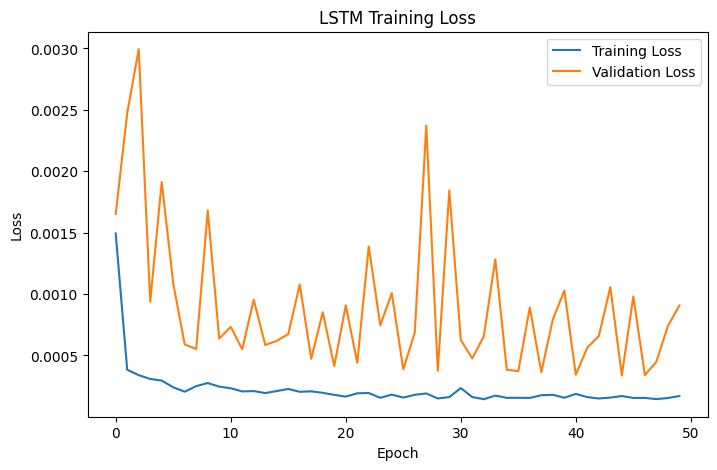

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MAE : 931.415471441236
RMSE: 1343.09300581139
MAPE: 0.027008659097716554


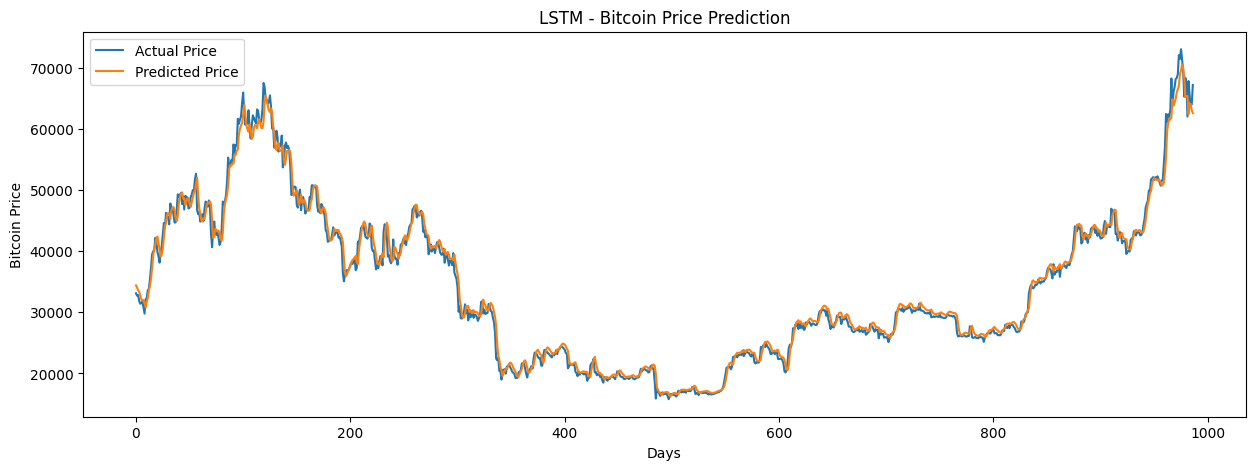

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

lstm_model = Sequential([
    LSTM(
        units=64,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

lstm_model.summary()

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1

)

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

y_pred_lstm = lstm_model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm)

mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm_actual))
mape_lstm = mean_absolute_percentage_error(y_test_actual, y_pred_lstm_actual)

print("MAE :", mae_lstm)
print("RMSE:", rmse_lstm)
print("MAPE:", mape_lstm)

plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(y_pred_lstm_actual, label="Predicted Price")

plt.title("LSTM - Bitcoin Price Prediction")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price")

plt.legend()
plt.show()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │      1,793 │ input_layer_3[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 60, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 1)     │          0 │ input_layer_3[0]… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 60, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 60, 1)     │        129 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,375 (9.28 KB)

 Trainable params: 2,375 (9.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.0211 - mae: 0.0763 - val_loss: 0.1962 - val_mae: 0.4058
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0834 - val_loss: 0.1893 - val_mae: 0.3971
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0847 - val_loss: 0.1916 - val_mae: 0.4000
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0198 - mae: 0.0841 - val_loss: 0.1906 - val_mae: 0.3987
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0198 - mae: 0.0846 - val_loss: 0.1910 - val_mae: 0.3992
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0198 - mae: 0.0848 - val_loss: 0.1940 - val_mae: 0.4030
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0198 - mae: 0.0842 - val_loss: 0.1916 - val_mae: 0.4000
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0845 - val_loss: 0.1919 - val_mae: 0.4004
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - 

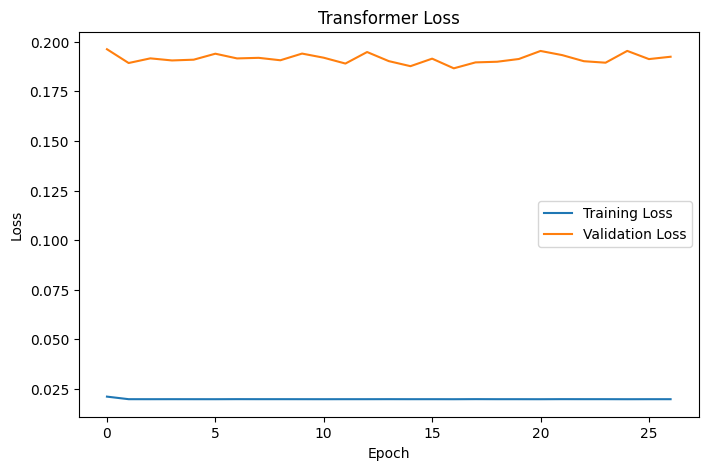

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
MAE : 28767.199625403682
RMSE: 31563.138426307076
MAPE: 0.8152303623150821


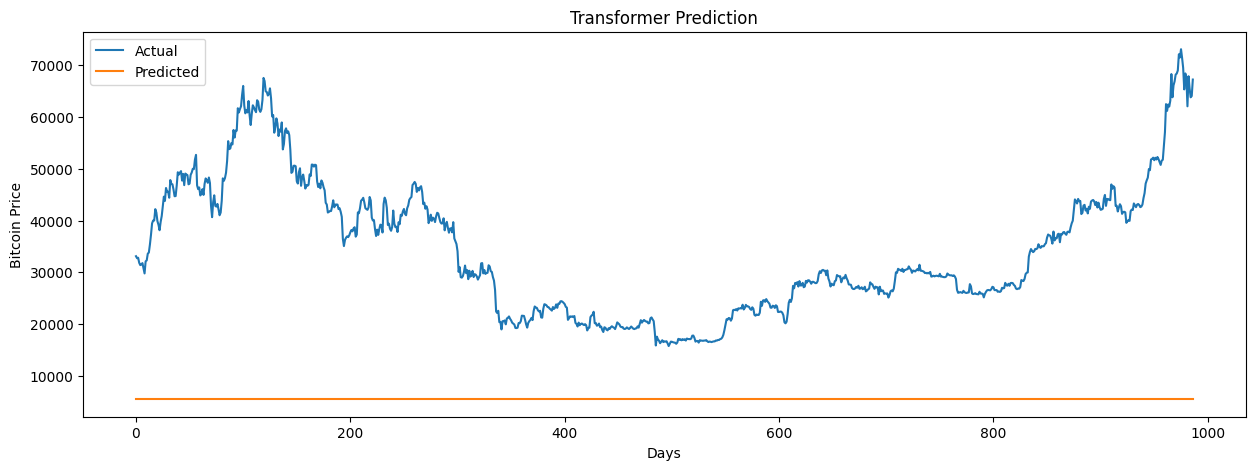

In [9]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(inputs + x)

    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(inputs.shape[-1])(ffn)

    x = LayerNormalization(epsilon=1e-6)(x + ffn)

    return x

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = transformer_encoder(
    inputs,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(1)(x)

transformer_model = Model(inputs, outputs)

transformer_model.summary()


transformer_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_transformer = transformer_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8,5))

plt.plot(history_transformer.history["loss"], label="Training Loss")
plt.plot(history_transformer.history["val_loss"], label="Validation Loss")

plt.title("Transformer Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

y_pred_transformer = transformer_model.predict(X_test)

y_test_actual = scaler.inverse_transform(y_test)
y_pred_transformer_actual = scaler.inverse_transform(y_pred_transformer)

mae_transformer = mean_absolute_error(
    y_test_actual,
    y_pred_transformer_actual
)

rmse_transformer = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_transformer_actual
    )
)

mape_transformer = mean_absolute_percentage_error(
    y_test_actual,
    y_pred_transformer_actual
)

print("MAE :", mae_transformer)
print("RMSE:", rmse_transformer)
print("MAPE:", mape_transformer)

plt.figure(figsize=(15,5))

plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_transformer_actual, label="Predicted")

plt.title("Transformer Prediction")

plt.xlabel("Days")
plt.ylabel("Bitcoin Price")

plt.legend()

plt.show()

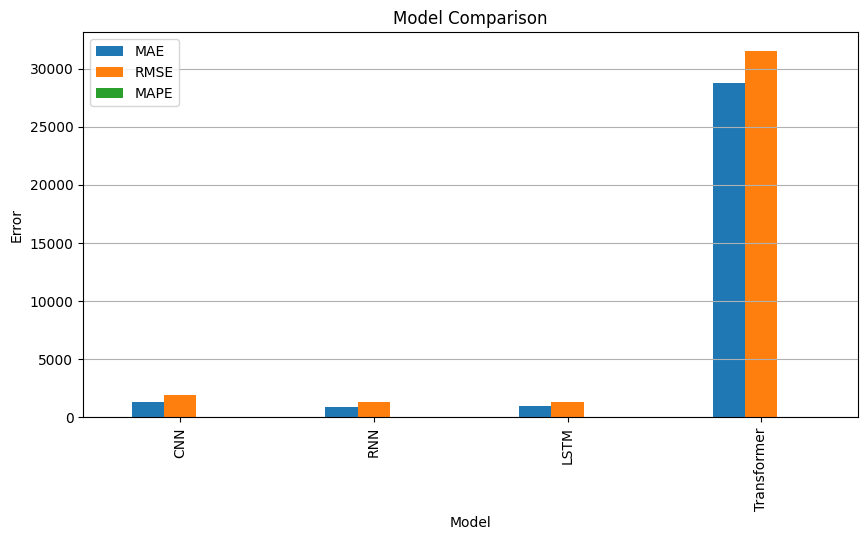

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": ["CNN", "RNN", "LSTM", "Transformer"],
    "MAE": [
        mae,
        mae_rnn,
        mae_lstm,
        mae_transformer
    ],
    "RMSE": [
        rmse,
        rmse_rnn,
        rmse_lstm,
        rmse_transformer
    ],
    "MAPE": [
        mape,
        mape_rnn,
        mape_lstm,
        mape_transformer
    ]
})

comparison

comparison.plot(
    x="Model",
    y=["MAE", "RMSE", "MAPE"],
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Error")
plt.grid(axis="y")

plt.show()

In [11]:
train_size_3d = int(len(X_3d) * 0.8)

X_train_3d = X_3d[:train_size_3d]
X_test_3d = X_3d[train_size_3d:]

y_train_3d = y_3d[:train_size_3d]
y_test_3d = y_3d[train_size_3d:]

print(X_train_3d.shape)
print(y_train_3d.shape)

(3944, 60, 1)
(3944, 3)


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout


def build_cnn(input_shape, output_size):

    model = Sequential([
        Conv1D(
            filters=64,
            kernel_size=3,
            activation="relu",
            input_shape=input_shape
        ),

        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(64, activation="relu"),

        Dropout(0.2),

        Dense(output_size)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

def train_model(model,
                X_train,
                y_train,
                X_test,
                y_test,
                epochs=50,
                batch_size=32):

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    return history

cnn_3d = build_cnn(
    input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]),
    output_size=3
)

cnn_3d.summary()

history_cnn_3d = train_model(
    cnn_3d,
    X_train_3d,
    y_train_3d,
    X_test_3d,
    y_test_3d
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,299 (466.01 KB)

 Trainable params: 119,299 (466.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0034 - mae: 0.0235 - val_loss: 0.0037 - val_mae: 0.0456
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - mae: 0.0169 - val_loss: 0.0022 - val_mae: 0.0344
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012 - mae: 0.0152 - val_loss: 0.0024 - val_mae: 0.0353
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0151 - val_loss: 0.0074 - val_mae: 0.0723
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - mae: 0.0156 - val_loss: 0.0016 - val_mae: 0.0302
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0153 - val_loss: 0.0017 - val_mae: 0.0293
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.5868e-04 - mae: 0.0150 - val_loss: 0.0014 - val_mae: 0.0278
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.5914e-04 - mae: 0.0142 - val_loss: 0.0052 - val_mae: 0.0606
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

def evaluate_model(model, X_test, y_test, scaler):

    predictions = model.predict(X_test)

    # Convert using min-max parameters manually
    actual = y_test * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

    predicted = predictions * (scaler.data_max_[0] - scaler.data_min_[0]) + scaler.data_min_[0]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    mape = mean_absolute_percentage_error(actual, predicted)

    return mae, rmse, mape, actual, predicted

mae_cnn_3d, rmse_cnn_3d, mape_cnn_3d, actual_cnn_3d, pred_cnn_3d = evaluate_model(
    cnn_3d,
    X_test_3d,
    y_test_3d,
    scaler
)

print("CNN 3-Day Forecast")
print("------------------")
print("MAE :", mae_cnn_3d)
print("RMSE:", rmse_cnn_3d)
print("MAPE:", mape_cnn_3d)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN 3-Day Forecast
------------------
MAE : 1570.7888380030215
RMSE: 2071.9004733843944
MAPE: 0.04953589979868939


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,403 (25.01 KB)

 Trainable params: 6,403 (25.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0020 - mae: 0.0185 - val_loss: 0.0016 - val_mae: 0.0293
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8474e-04 - mae: 0.0109 - val_loss: 0.0012 - val_mae: 0.0253
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1053e-04 - mae: 0.0093 - val_loss: 7.6143e-04 - val_mae: 0.0201
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.5428e-04 - mae: 0.0089 - val_loss: 6.6967e-04 - val_mae: 0.0186
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.2007e-04 - mae: 0.0082 - val_loss: 8.4191e-04 - val_mae: 0.0216
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.1587e-04 - mae: 0.0084 - val_loss: 8.9305e-04 - val_mae: 0.0218
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9948e-04 - mae: 0.0076 - val_loss: 6.3271e-04 - val_mae: 0.0172
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.3597e-04 - mae: 0.0074 - val_loss: 6.6670e-04 - val_mae: 0.0182
Epo

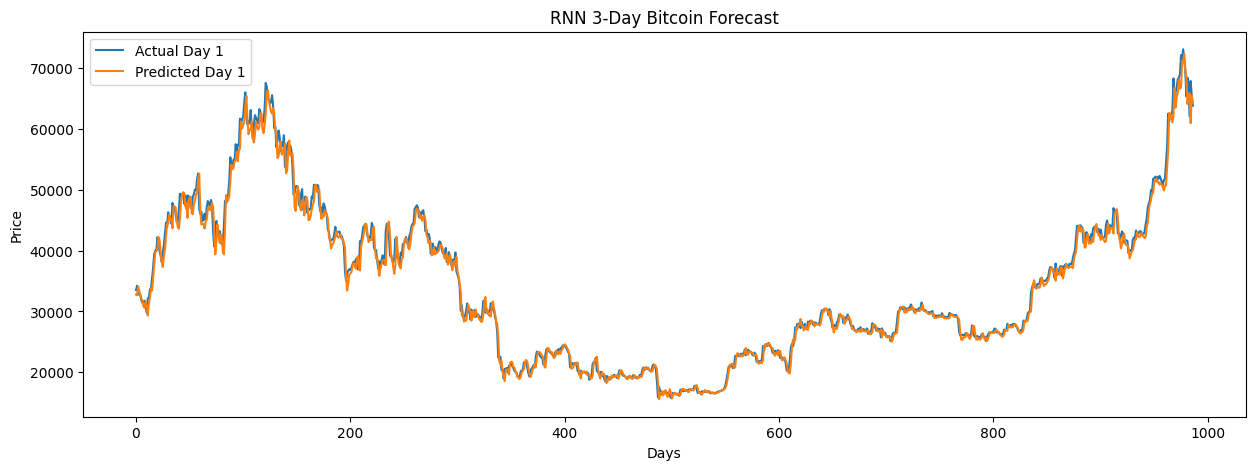

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout


def build_rnn(input_shape, output_size):

    model = Sequential([
        SimpleRNN(
            units=64,
            activation="tanh",
            input_shape=input_shape
        ),

        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(output_size)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

rnn_3d = build_rnn(
    input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]),
    output_size=3
)

rnn_3d.summary()

history_rnn_3d = train_model(
    rnn_3d,
    X_train_3d,
    y_train_3d,
    X_test_3d,
    y_test_3d
)

mae_rnn_3d, rmse_rnn_3d, mape_rnn_3d, actual_rnn_3d, pred_rnn_3d = evaluate_model(
    rnn_3d,
    X_test_3d,
    y_test_3d,
    scaler
)

print("RNN 3-Day Forecast")
print("------------------")
print("MAE :", mae_rnn_3d)
print("RMSE:", rmse_rnn_3d)
print("MAPE:", mape_rnn_3d)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(actual_rnn_3d[:,0], label="Actual Day 1")
plt.plot(pred_rnn_3d[:,0], label="Predicted Day 1")

plt.title("RNN 3-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,075 (74.51 KB)

 Trainable params: 19,075 (74.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0023 - mae: 0.0200 - val_loss: 0.0014 - val_mae: 0.0260
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0336e-04 - mae: 0.0100 - val_loss: 0.0013 - val_mae: 0.0244
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.1967e-04 - mae: 0.0093 - val_loss: 0.0012 - val_mae: 0.0265
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.2449e-04 - mae: 0.0092 - val_loss: 0.0015 - val_mae: 0.0262
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0946e-04 - mae: 0.0094 - val_loss: 0.0011 - val_mae: 0.0223
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6591e-04 - mae: 0.0093 - val_loss: 0.0014 - val_mae: 0.0254
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.1151e-04 - mae: 0.0085 - val_loss: 0.0013 - val_mae: 0.0246
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0874e-04 - mae: 0.0081 - val_loss: 9.0919e-04 - val_mae: 0.0226
Epoch 9/50
124/124 ━━

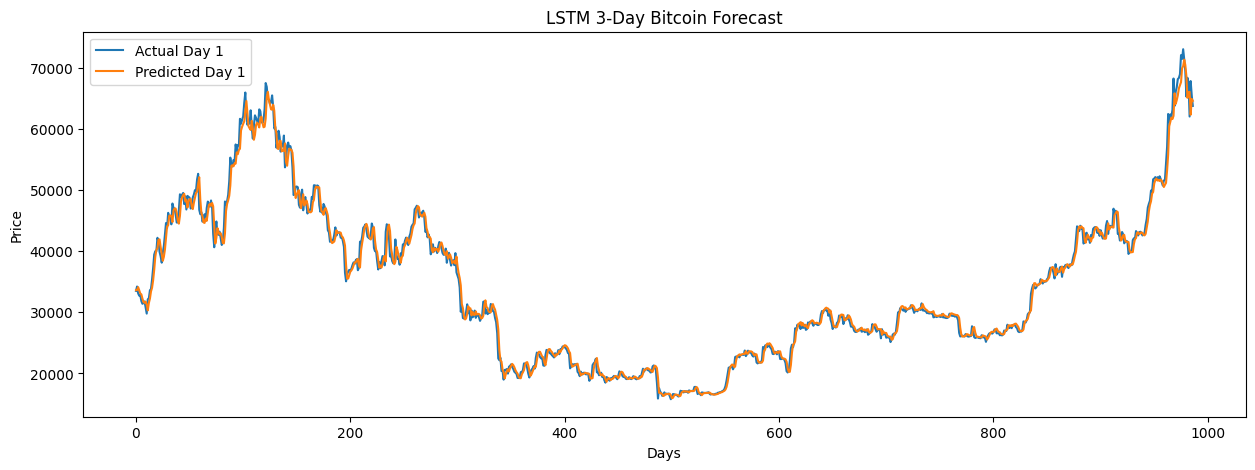

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


def build_lstm(input_shape, output_size):

    model = Sequential([
        LSTM(
            units=64,
            input_shape=input_shape
        ),

        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(output_size)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

lstm_3d = build_lstm(
    input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]),
    output_size=3
)

lstm_3d.summary()

history_lstm_3d = train_model(
    lstm_3d,
    X_train_3d,
    y_train_3d,
    X_test_3d,
    y_test_3d
)

mae_lstm_3d, rmse_lstm_3d, mape_lstm_3d, actual_lstm_3d, pred_lstm_3d = evaluate_model(
    lstm_3d,
    X_test_3d,
    y_test_3d,
    scaler
)

print("LSTM 3-Day Forecast")
print("-------------------")
print("MAE :", mae_lstm_3d)
print("RMSE:", rmse_lstm_3d)
print("MAPE:", mape_lstm_3d)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(actual_lstm_3d[:,0], label="Actual Day 1")
plt.plot(pred_lstm_3d[:,0], label="Predicted Day 1")

plt.title("LSTM 3-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │      1,793 │ input_layer_7[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 60, 1)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 60, 1)     │          0 │ input_layer_7[0]… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 60, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 60, 1)     │        129 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 60, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 3)         │        195 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,505 (9.79 KB)

 Trainable params: 2,505 (9.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 0.0210 - mae: 0.0754 - val_loss: 0.1945 - val_mae: 0.4038
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0834 - val_loss: 0.1883 - val_mae: 0.3961
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0851 - val_loss: 0.1921 - val_mae: 0.4009
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0838 - val_loss: 0.1906 - val_mae: 0.3990
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0846 - val_loss: 0.1910 - val_mae: 0.3994
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0844 - val_loss: 0.1902 - val_mae: 0.3985
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0847 - val_loss: 0.1937 - val_mae: 0.4028
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0198 - mae: 0.0843 - val_loss: 0.1913 - val_mae: 0.3998
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - 

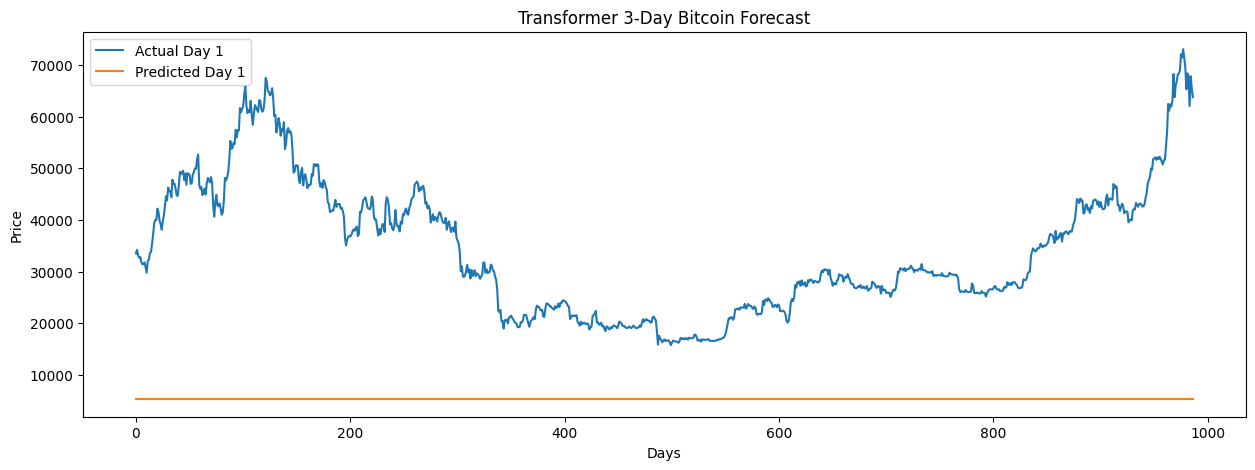

In [17]:
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model


def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.2):

    attention = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(attention)

    x = LayerNormalization(epsilon=1e-6)(
        inputs + attention
    )

    ffn = Dense(
        ff_dim,
        activation="relu"
    )(x)

    ffn = Dense(
        inputs.shape[-1]
    )(ffn)

    x = LayerNormalization(epsilon=1e-6)(
        x + ffn
    )

    return x


def build_transformer(input_shape, output_size):

    inputs = Input(shape=input_shape)

    x = transformer_encoder(
        inputs,
        head_size=64,
        num_heads=4,
        ff_dim=128,
        dropout=0.2
    )

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        64,
        activation="relu"
    )(x)

    x = Dropout(0.2)(x)

    outputs = Dense(output_size)(x)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

transformer_3d = build_transformer(
    input_shape=(
        X_train_3d.shape[1],
        X_train_3d.shape[2]
    ),
    output_size=3
)

transformer_3d.summary()

history_transformer_3d = train_model(
    transformer_3d,
    X_train_3d,
    y_train_3d,
    X_test_3d,
    y_test_3d
)

mae_transformer_3d, rmse_transformer_3d, mape_transformer_3d, actual_transformer_3d, pred_transformer_3d = evaluate_model(
    transformer_3d,
    X_test_3d,
    y_test_3d,
    scaler
)

print("Transformer 3-Day Forecast")
print("--------------------------")
print("MAE :", mae_transformer_3d)
print("RMSE:", rmse_transformer_3d)
print("MAPE:", mape_transformer_3d)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    actual_transformer_3d[:,0],
    label="Actual Day 1"
)

plt.plot(
    pred_transformer_3d[:,0],
    label="Predicted Day 1"
)

plt.title("Transformer 3-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

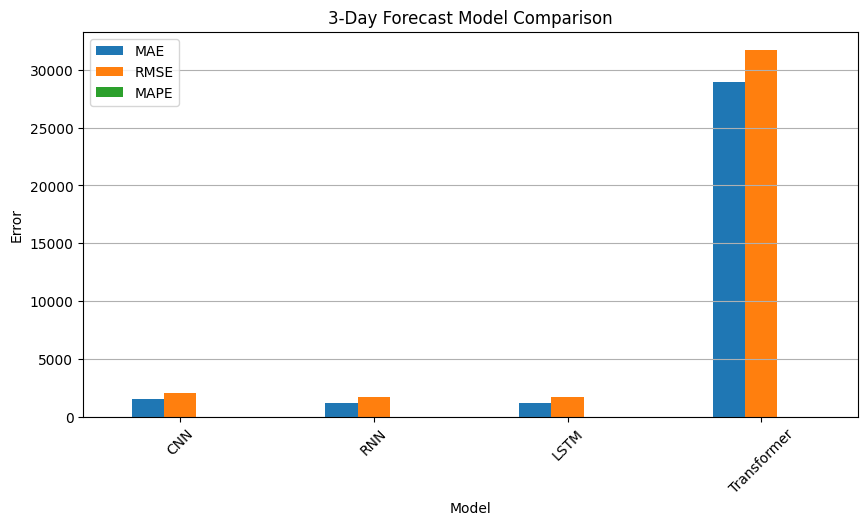

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_3d = pd.DataFrame({
    "Model": [
        "CNN",
        "RNN",
        "LSTM",
        "Transformer"
    ],

    "MAE": [
        mae_cnn_3d,
        mae_rnn_3d,
        mae_lstm_3d,
        mae_transformer_3d
    ],

    "RMSE": [
        rmse_cnn_3d,
        rmse_rnn_3d,
        rmse_lstm_3d,
        rmse_transformer_3d
    ],

    "MAPE": [
        mape_cnn_3d,
        mape_rnn_3d,
        mape_lstm_3d,
        mape_transformer_3d
    ]
})



comparison_3d.plot(
    x="Model",
    y=["MAE", "RMSE", "MAPE"],
    kind="bar",
    figsize=(10,5)
)

plt.title("3-Day Forecast Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [19]:
train_size_7d = int(len(X_7d) * 0.8)

X_train_7d = X_7d[:train_size_7d]
X_test_7d = X_7d[train_size_7d:]

y_train_7d = y_7d[:train_size_7d]
y_test_7d = y_7d[train_size_7d:]


print(X_train_7d.shape)
print(y_train_7d.shape)

(3941, 60, 1)
(3941, 7)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,559 (467.03 KB)

 Trainable params: 119,559 (467.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0039 - mae: 0.0258 - val_loss: 0.0104 - val_mae: 0.0780
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0022 - mae: 0.0201 - val_loss: 0.0096 - val_mae: 0.0787
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015 - mae: 0.0181 - val_loss: 0.0087 - val_mae: 0.0748
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - mae: 0.0181 - val_loss: 0.0025 - val_mae: 0.0356
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - mae: 0.0170 - val_loss: 0.0026 - val_mae: 0.0383
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012 - mae: 0.0161 - val_loss: 0.0023 - val_mae: 0.0336
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - mae: 0.0164 - val_loss: 0.0045 - val_mae: 0.0512
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - mae: 0.0154 - val_loss: 0.0022 - val_mae: 0.0324
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

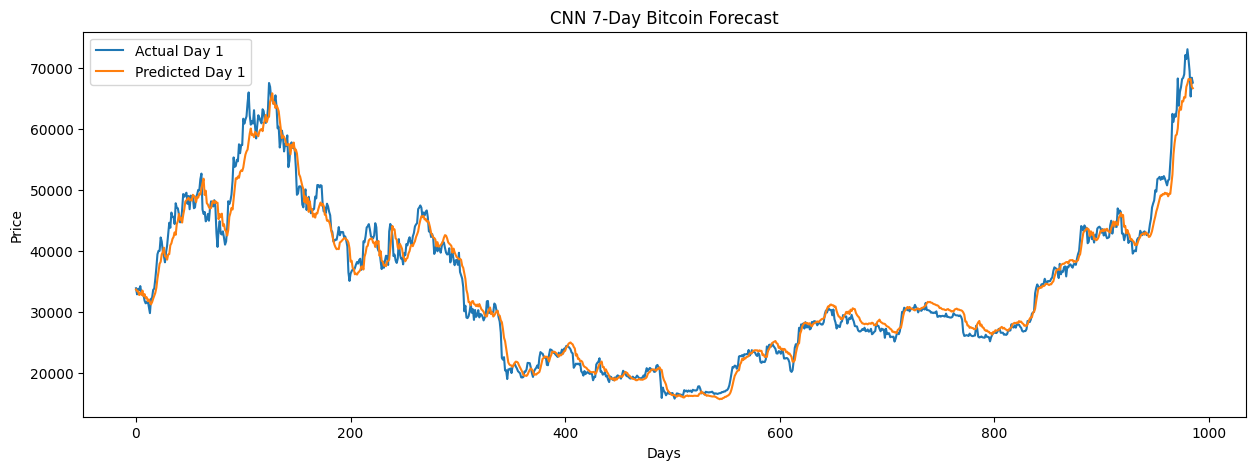

In [20]:
import matplotlib.pyplot as plt

cnn_7d = build_cnn(
    input_shape=(
        X_train_7d.shape[1],
        X_train_7d.shape[2]
    ),
    output_size=7
)

cnn_7d.summary()

history_cnn_7d = train_model(
    cnn_7d,
    X_train_7d,
    y_train_7d,
    X_test_7d,
    y_test_7d
)

mae_cnn_7d, rmse_cnn_7d, mape_cnn_7d, actual_cnn_7d, pred_cnn_7d = evaluate_model(
    cnn_7d,
    X_test_7d,
    y_test_7d,
    scaler
)

print("CNN 7-Day Forecast")
print("------------------")
print("MAE :", mae_cnn_7d)
print("RMSE:", rmse_cnn_7d)
print("MAPE:", mape_cnn_7d)



plt.figure(figsize=(15,5))

plt.plot(
    actual_cnn_7d[:,0],
    label="Actual Day 1"
)

plt.plot(
    pred_cnn_7d[:,0],
    label="Predicted Day 1"
)

plt.title("CNN 7-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,535 (25.53 KB)

 Trainable params: 6,535 (25.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0027 - mae: 0.0210 - val_loss: 0.0019 - val_mae: 0.0305
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.7836e-04 - mae: 0.0123 - val_loss: 0.0024 - val_mae: 0.0362
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.3055e-04 - mae: 0.0104 - val_loss: 0.0020 - val_mae: 0.0321
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.3422e-04 - mae: 0.0108 - val_loss: 0.0012 - val_mae: 0.0238
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9233e-04 - mae: 0.0097 - val_loss: 0.0027 - val_mae: 0.0378
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.3808e-04 - mae: 0.0102 - val_loss: 0.0012 - val_mae: 0.0236
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.1325e-04 - mae: 0.0090 - val_loss: 0.0022 - val_mae: 0.0349
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.0787e-04 - mae: 0.0093 - val_loss: 0.0012 - val_mae: 0.0229
Epoch 9/50
124/124 ━━━━━━━━

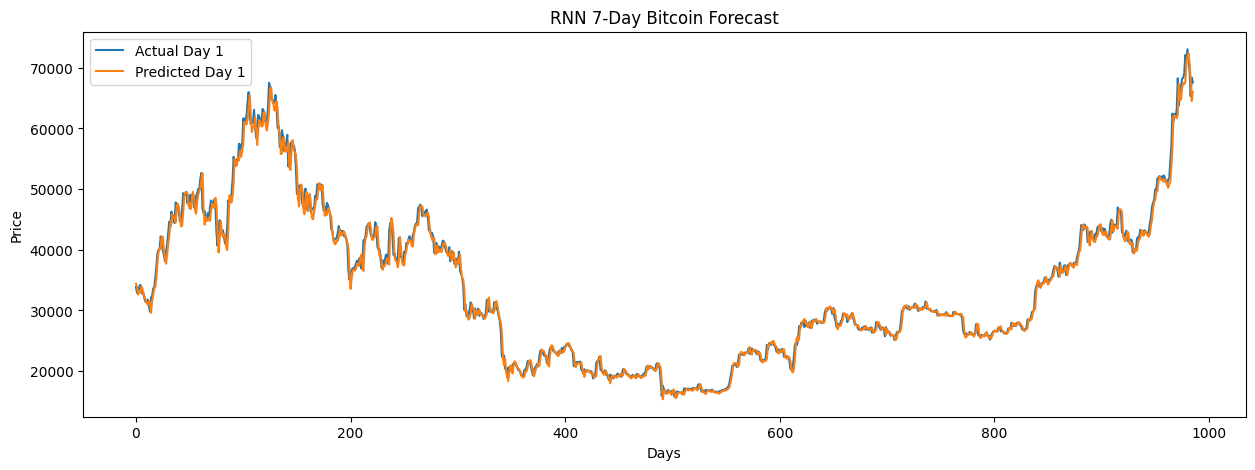

In [21]:
import matplotlib.pyplot as plt

rnn_7d = build_rnn(
    input_shape=(
        X_train_7d.shape[1],
        X_train_7d.shape[2]
    ),
    output_size=7
)

rnn_7d.summary()

history_rnn_7d = train_model(
    rnn_7d,
    X_train_7d,
    y_train_7d,
    X_test_7d,
    y_test_7d
)

mae_rnn_7d, rmse_rnn_7d, mape_rnn_7d, actual_rnn_7d, pred_rnn_7d = evaluate_model(
    rnn_7d,
    X_test_7d,
    y_test_7d,
    scaler
)

print("RNN 7-Day Forecast")
print("------------------")
print("MAE :", mae_rnn_7d)
print("RMSE:", rmse_rnn_7d)
print("MAPE:", mape_rnn_7d)



plt.figure(figsize=(15,5))

plt.plot(
    actual_rnn_7d[:,0],
    label="Actual Day 1"
)

plt.plot(
    pred_rnn_7d[:,0],
    label="Predicted Day 1"
)

plt.title("RNN 7-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,207 (75.03 KB)

 Trainable params: 19,207 (75.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0029 - mae: 0.0241 - val_loss: 0.0022 - val_mae: 0.0321
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 7.7415e-04 - mae: 0.0123 - val_loss: 0.0023 - val_mae: 0.0370
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 6.2664e-04 - mae: 0.0111 - val_loss: 0.0020 - val_mae: 0.0299
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.9994e-04 - mae: 0.0119 - val_loss: 0.0020 - val_mae: 0.0302
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 4.8617e-04 - mae: 0.0098 - val_loss: 0.0017 - val_mae: 0.0309
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.3717e-04 - mae: 0.0093 - val_loss: 0.0024 - val_mae: 0.0333
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.8116e-04 - mae: 0.0098 - val_loss: 0.0015 - val_mae: 0.0294
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.7014e-04 - mae: 0.0098 - val_loss: 0.0017 - val_mae: 0.0285
Epoch 9/50
124/124 ━━━━━━

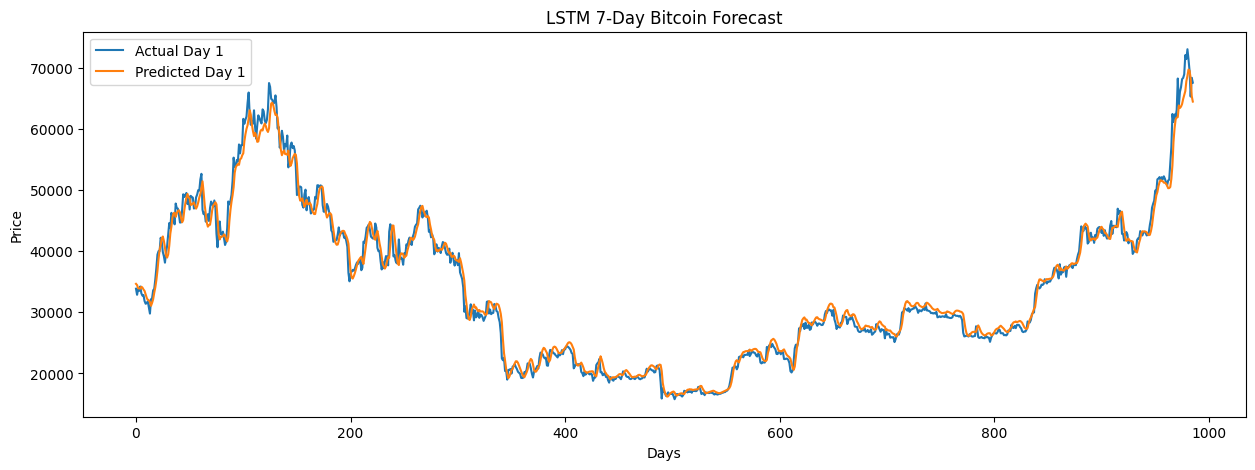

In [22]:
import matplotlib.pyplot as plt

lstm_7d = build_lstm(
    input_shape=(
        X_train_7d.shape[1],
        X_train_7d.shape[2]
    ),
    output_size=7
)

lstm_7d.summary()

history_lstm_7d = train_model(
    lstm_7d,
    X_train_7d,
    y_train_7d,
    X_test_7d,
    y_test_7d
)

mae_lstm_7d, rmse_lstm_7d, mape_lstm_7d, actual_lstm_7d, pred_lstm_7d = evaluate_model(
    lstm_7d,
    X_test_7d,
    y_test_7d,
    scaler
)

print("LSTM 7-Day Forecast")
print("-------------------")
print("MAE :", mae_lstm_7d)
print("RMSE:", rmse_lstm_7d)
print("MAPE:", mape_lstm_7d)



plt.figure(figsize=(15,5))

plt.plot(
    actual_lstm_7d[:,0],
    label="Actual Day 1"
)

plt.plot(
    pred_lstm_7d[:,0],
    label="Predicted Day 1"
)

plt.title("LSTM 7-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 1)     │      1,793 │ input_layer_11[0… │
│ (MultiHeadAttentio… │                   │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 60, 1)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 60, 1)     │          0 │ input_layer_11[0… │
│                     │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 60, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 60, 1)     │        129 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 60, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 1)     │          2 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ dense_28[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 7)         │        455 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,765 (10.80 KB)

 Trainable params: 2,765 (10.80 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - loss: 0.0207 - mae: 0.0768 - val_loss: 0.1895 - val_mae: 0.3980
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0198 - mae: 0.0844 - val_loss: 0.1893 - val_mae: 0.3977
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0197 - mae: 0.0837 - val_loss: 0.1886 - val_mae: 0.3969
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0197 - mae: 0.0847 - val_loss: 0.1899 - val_mae: 0.3985
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0197 - mae: 0.0842 - val_loss: 0.1895 - val_mae: 0.3981
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0197 - mae: 0.0843 - val_loss: 0.1858 - val_mae: 0.3934
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0197 - mae: 0.0845 - val_loss: 0.1914 - val_mae: 0.4004
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0197 - mae: 0.0838 - val_loss: 0.1882 - val_mae: 0.3964
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - 

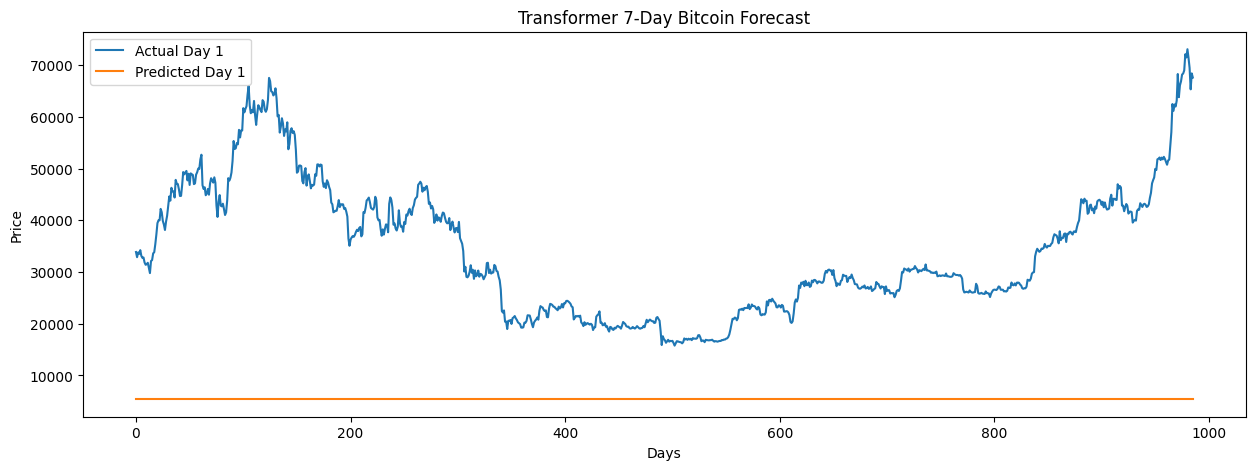

In [23]:
import matplotlib.pyplot as plt

transformer_7d = build_transformer(
    input_shape=(
        X_train_7d.shape[1],
        X_train_7d.shape[2]
    ),
    output_size=7
)

transformer_7d.summary()

history_transformer_7d = train_model(
    transformer_7d,
    X_train_7d,
    y_train_7d,
    X_test_7d,
    y_test_7d
)

mae_transformer_7d, rmse_transformer_7d, mape_transformer_7d, actual_transformer_7d, pred_transformer_7d = evaluate_model(
    transformer_7d,
    X_test_7d,
    y_test_7d,
    scaler
)

print("Transformer 7-Day Forecast")
print("--------------------------")
print("MAE :", mae_transformer_7d)
print("RMSE:", rmse_transformer_7d)
print("MAPE:", mape_transformer_7d)



plt.figure(figsize=(15,5))

plt.plot(
    actual_transformer_7d[:,0],
    label="Actual Day 1"
)

plt.plot(
    pred_transformer_7d[:,0],
    label="Predicted Day 1"
)

plt.title("Transformer 7-Day Bitcoin Forecast")
plt.xlabel("Days")
plt.ylabel("Price")

plt.legend()
plt.show()

In [25]:
comparison_1d = pd.DataFrame({
    "Model": [
        "CNN",
        "RNN",
        "LSTM",
        "Transformer"
    ],

    "MAE": [
        mae,
        mae_rnn,
        mae_lstm,
        mae_transformer
    ],

    "RMSE": [
        rmse,
        rmse_rnn,
        rmse_lstm,
        rmse_transformer
    ],

    "MAPE": [
        mape,
        mape_rnn,
        mape_lstm,
        mape_transformer
    ]
})

comparison_1d

comparison_3d = pd.DataFrame({

    "Model": [
        "CNN",
        "RNN",
        "LSTM",
        "Transformer"
    ],

    "MAE": [
        mae_cnn_3d,
        mae_rnn_3d,
        mae_lstm_3d,
        mae_transformer_3d
    ],

    "RMSE": [
        rmse_cnn_3d,
        rmse_rnn_3d,
        rmse_lstm_3d,
        rmse_transformer_3d
    ],

    "MAPE": [
        mape_cnn_3d,
        mape_rnn_3d,
        mape_lstm_3d,
        mape_transformer_3d
    ]
})

comparison_3d

comparison_7d = pd.DataFrame({

    "Model": [
        "CNN",
        "RNN",
        "LSTM",
        "Transformer"
    ],

    "MAE": [
        mae_cnn_7d,
        mae_rnn_7d,
        mae_lstm_7d,
        mae_transformer_7d
    ],

    "RMSE": [
        rmse_cnn_7d,
        rmse_rnn_7d,
        rmse_lstm_7d,
        rmse_transformer_7d
    ],

    "MAPE": [
        mape_cnn_7d,
        mape_rnn_7d,
        mape_lstm_7d,
        mape_transformer_7d
    ]
})

comparison_7d

final_comparison = pd.concat([
    comparison_1d.assign(Horizon="1-Day"),
    comparison_3d.assign(Horizon="3-Day"),
    comparison_7d.assign(Horizon="7-Day")
])

final_comparison

best_model = final_comparison.loc[
    final_comparison["MAE"].idxmin()
]

best_model

final_comparison.to_csv(
    "Bitcoin_Model_Comparison.csv",
    index=False
)

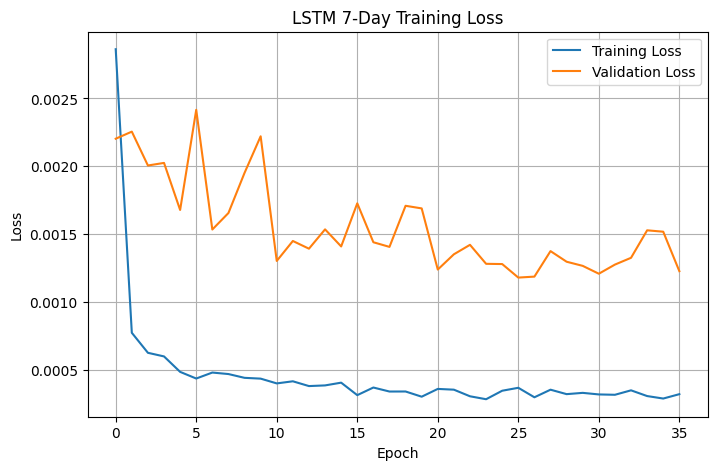

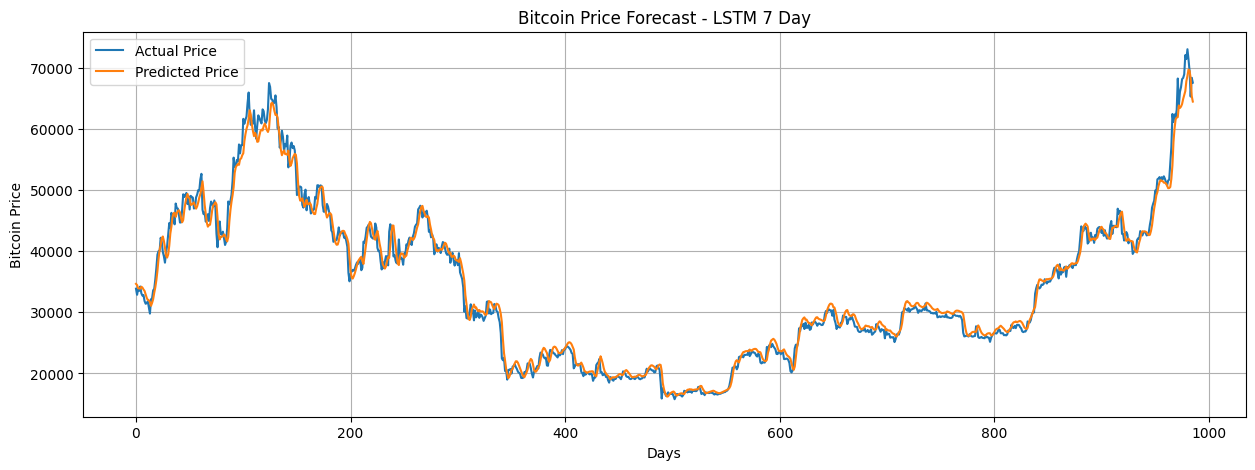

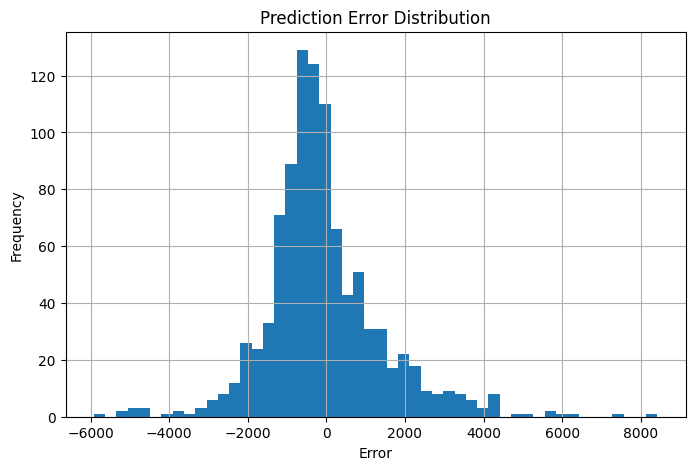

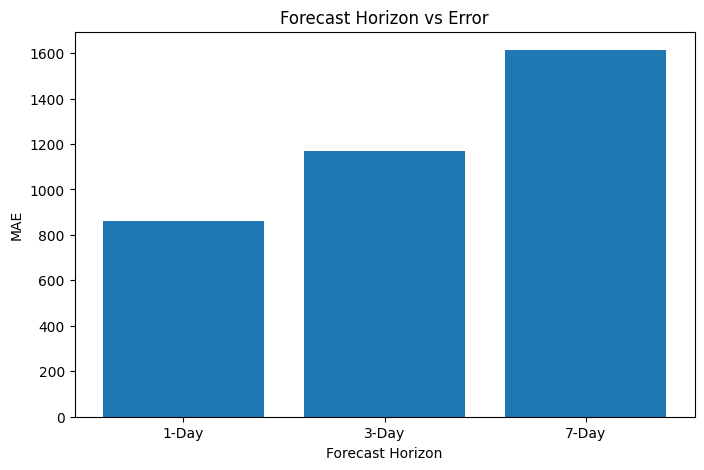

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_lstm_7d.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm_7d.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM 7-Day Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(15,5))

plt.plot(
    actual_lstm_7d[:,0],
    label="Actual Price"
)

plt.plot(
    pred_lstm_7d[:,0],
    label="Predicted Price"
)

plt.title("Bitcoin Price Forecast - LSTM 7 Day")
plt.xlabel("Days")
plt.ylabel("Bitcoin Price")

plt.legend()
plt.grid(True)

plt.show()

errors = actual_lstm_7d[:,0] - pred_lstm_7d[:,0]

plt.figure(figsize=(8,5))

plt.hist(errors, bins=50)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

horizon_comparison = pd.DataFrame({
    "Horizon": [
        "1-Day",
        "3-Day",
        "7-Day"
    ],

    "Best MAE": [
        comparison_1d["MAE"].min(),
        comparison_3d["MAE"].min(),
        comparison_7d["MAE"].min()
    ]
})

horizon_comparison

plt.figure(figsize=(8,5))

plt.bar(
    horizon_comparison["Horizon"],
    horizon_comparison["Best MAE"]
)

plt.title("Forecast Horizon vs Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("MAE")

plt.show()

cnn_7d.save("CNN_7Day.keras")

rnn_7d.save("RNN_7Day.keras")

lstm_7d.save("LSTM_7Day.keras")

transformer_7d.save("Transformer_7Day.keras")

In [27]:
import pickle

with open("bitcoin_scaler.pkl","wb") as file:
    pickle.dump(scaler,file)

In [31]:
best_model = final_comparison.loc[
    final_comparison["MAE"].idxmin()
]

best_model

,Model,MAE,RMSE,MAPE,Horizon
1,RNN,863.209017,1314.750032,0.023934,1-Day
1,RNN,1170.422255,1720.348965,0.033358,3-Day
1,RNN,1613.498543,2360.313083,0.047143,7-Day


In [29]:
lstm_7d.save("Best_Bitcoin_Model.keras")

In [39]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

X_test shape: (987, 60, 1)
y_test shape: (987, 1)
y_pred shape: (987, 7)


In [40]:
from tensorflow.keras.models import load_model

best_model = load_model("Best_Bitcoin_Model.keras")

actual_pred_df = pd.DataFrame({
    "Actual Price": actual_rnn_7d[:, 0],
    "Predicted Price": pred_rnn_7d[:, 0]
})

actual_pred_df.to_csv("Actual_vs_Predicted.csv", index=False)

In [41]:
errors = actual_rnn_7d[:, 0] - pred_rnn_7d[:, 0]

error_df = pd.DataFrame({
    "Error": errors
})

error_df.to_csv("Prediction_Error.csv", index=False)

In [42]:
horizon_comparison.to_csv(
    "Forecast_Horizon.csv",
    index=False
)

In [43]:
loss_df = pd.DataFrame({
    "Epoch": range(1, len(history_lstm_7d.history["loss"]) + 1),
    "Training Loss": history_lstm_7d.history["loss"],
    "Validation Loss": history_lstm_7d.history["val_loss"]
})

loss_df.to_csv(
    "Training_Loss.csv",
    index=False
)

In [44]:
import numpy as np
import pickle
from tensorflow.keras.models import load_model


def predict_future_prices(model, scaler, recent_data, days):

    # Scale input data
    scaled_input = scaler.transform(
        recent_data.reshape(-1,1)
    )

    # Take last 60 days
    X_input = scaled_input[-60:]

    # Reshape for model
    X_input = X_input.reshape(
        1,
        60,
        1
    )

    # Predict
    prediction = model.predict(X_input)

    # Convert back to original price
    prediction = (
        prediction *
        (scaler.data_max_[0] - scaler.data_min_[0])
        +
        scaler.data_min_[0]
    )

    return prediction

latest_prices = df["Price"].values[-60:]

future_prices = predict_future_prices(
    lstm_7d,
    scaler,
    latest_prices,
    7
)

future_prices

last_date = df["Date"].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7
)


forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Price": future_prices.flatten()
})


forecast_df


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,Date,Predicted_Price
0,2024-03-25,63129.398604
1,2024-03-26,64039.946689
2,2024-03-27,63109.439250
3,2024-03-28,62881.211026
4,2024-03-29,62568.751105
5,2024-03-30,62594.899035
6,2024-03-31,62665.015902


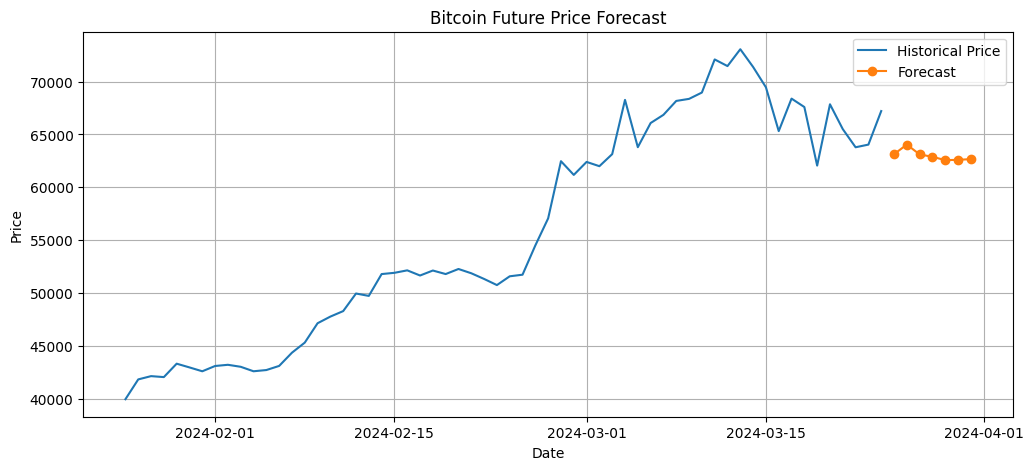

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df["Date"].tail(60),
    df["Price"].tail(60),
    label="Historical Price"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted_Price"],
    marker="o",
    label="Forecast"
)

plt.title("Bitcoin Future Price Forecast")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

In [46]:
final_comparison.to_csv("Bitcoin_Model_Comparison.csv", index=False)

In [47]:
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(history_lstm_7d.history, f)

forecast_df.to_csv("Future_Forecast.csv", index=False)

In [50]:
from google.colab import files

files.download("Best_Bitcoin_Model.keras")
files.download("bitcoin_scaler.pkl")
files.download("Bitcoin Historical Data.csv")
files.download("Bitcoin_Model_Comparison.csv")
files.download("training_history.pkl")
files.download("Future_Forecast.csv")
files.download("Actual_vs_Predicted.csv")
files.download("Prediction_Error.csv")
files.download("Forecast_Horizon.csv")
files.download("Training_Loss.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>